In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from scipy.stats import chi2
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [25]:
araport=pd.read_table('Araport11_GFF3_genes_transposons.201606.gff.gz',skiprows=1,header=None)
araport.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
1,Chr1,Araport11,mRNA,3631.0,5899.0,.,+,.,ID=AT1G01010.1;Parent=AT1G01010;Name=AT1G01010...
2,Chr1,Araport11,five_prime_UTR,3631.0,3759.0,.,+,.,ID=AT1G01010:five_prime_UTR:1;Parent=AT1G01010...
3,Chr1,Araport11,exon,3631.0,3913.0,.,+,.,ID=AT1G01010:exon:1;Parent=AT1G01010.1;Name=NA...
4,Chr1,Araport11,CDS,3760.0,3913.0,.,+,0,ID=AT1G01010:CDS:1;Parent=AT1G01010.1;Name=NAC...


In [26]:
araport_gene=araport.loc[araport[2]=='gene']
araport_gene.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...


In [27]:
araport_gene['gene']=araport_gene[8].astype(str).str[3:12]
araport_gene.head()

<ipython-input-27-202a01519162>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  araport_gene['gene']=araport_gene[8].astype(str).str[3:12]


,0,1,2,3,4,5,6,7,8,gene
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...,AT1G01010
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...,AT1G01020
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...,AT1G03987
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...,AT1G01030
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...,AT1G01040


In [35]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)
all_site=parse('166_Mg_blues.assoc.txt.gz')
covariate=parse('166_Mg_blues_chr5_21394004.assoc.txt.gz')

In [36]:
all_site[all_site['P'] > -np.log10(0.05/len(all_site))].shape

(21, 17)

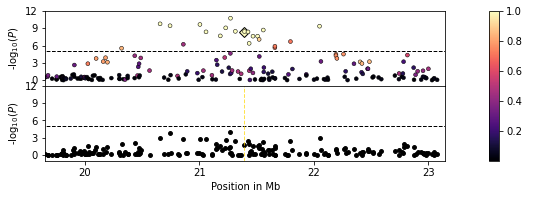

In [37]:
start = 19650000
end = 23150000

classic=all_site.loc[(all_site['chr'] == 5) &
                (all_site['ps'] > start) &
                (all_site['ps'] < end)]


covariate=covariate.loc[(covariate['chr'] == 5) &
                (covariate['ps'] > start) &
                (covariate['ps'] < end)]

Chr5_282011_ld=pd.read_table('Chr5_21394004.ld', sep = '\s+')
Chr5_282011_ld.head()
#Combine LD info and zoom
zoom=pd.merge(classic,Chr5_282011_ld,left_on='ps',right_on='BP_B')
# print(zoom.head())

# Import araport info
araport_zoom=araport_gene.loc[(araport_gene[0] == 'Chr5') & (araport_gene[3] > start) & (araport_gene[3] < end)]

#Import color information
colors = plt.cm.magma(np.linspace(0,1,5))

def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y

from matplotlib.gridspec import GridSpec

cm = 1/2.54
fig = plt.figure(figsize=(22*cm,7*cm))
# fig = plt.figure(figsize=(10,10))
gs = GridSpec(4, 6, figure=fig, hspace=0)
ax1 = fig.add_subplot(gs[:2,:5])
ax1=sns.scatterplot(x='ps',
                y='P',
                data=zoom,
                palette='magma',
                hue='R2',
                marker='o',
                s=15,
                linewidth=0.5,
                edgecolor='k',
                legend=False,
                zorder=2)
y_SNP = zoom.loc[zoom['ps'] == 21394004,'P'].values
ax1.plot(21394004,y_SNP,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax1.hlines(y=-np.log10(0.05/len(all_site)),
           xmin=min(all_site['position']),
           xmax=max(all_site['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax1.set_xlim(start,end)
ax1.set_ylim(-1,12)
ax1.set_xlabel('')
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.set_xticklabels([])
# ax1.annotate('all SNPs',xy=(19800000,8.2),xytext=(19800000,8.2),fontsize=8)
# ax1.annotate('$\itMGR5$ L77fs',xy=(19800000,8.2),xytext=(19800000,8.2),fontsize=8)
ax1.axes.get_xaxis().set_visible(False)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(3))
# ax1.spines["bottom"].set_visible(False) 



ax3 = fig.add_subplot(gs[2:4,:5])
ax3=sns.scatterplot(x='ps',
                y='P',
                data=covariate,
                color='k',
                s=15,
                linewidth=1,
                edgecolor='k',
                legend=False,
                zorder=2)
ax3.hlines(y=-np.log10(0.05/len(all_site)),
                 xmin=min(all_site['position']),
                 xmax=max(all_site['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
ax3.set_xlim(start,end)
ax3.set_ylim(-1,12)
ax3.set_xlabel('')
ax3.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax3.set_xticklabels([])
ax3.yaxis.set_major_locator(ticker.MultipleLocator(5))
# ax3.annotate('w. $\itMGR5$ T76fs',xy=(19800000,8.2),xytext=(19800000,8.2),fontsize=8)
ax3.axvline(x=21394004,linewidth=1,linestyle='--',color='gold',alpha=0.7)

ax3.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(3))
ax3.xaxis.set_major_formatter(major_formatter)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1000000))
# ax3.annotate('chr5:282011',xy=(261000,15),xytext=(261000,15),fontsize=8)




ax3.set_xlabel('Position in Mb',fontsize=10)

# Add legend
norm = plt.Normalize(zoom['R2'].min(), zoom['R2'].max())
sm = plt.cm.ScalarMappable(norm=norm,cmap='magma')
sm.set_array([])
ax3 = fig.add_subplot(gs[:,5])
ax3.axis('off')
# ax3.get_legend().remove()
axins = inset_axes(ax3,
                    width="15%",  
                    height="100%",
                    loc='center',
                    borderpad=-5
                   )
ax3.figure.colorbar(sm,pad=0.05,shrink=0.8,cax=axins,orientation="vertical")
plt.savefig("Fig4b_20250108.pdf", format="pdf",bbox_inches="tight")
plt.savefig("Fig4b_20250108.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)